# Formal held-out FPR — chronological split

The headline defensible metric, measured the
way production would experience it: per connector, the **most recent 20% of
sessions are held out**, models retrain on the older 80%, and the held-out
normals are scored at the deployed threshold. A flag on a held-out normal
session is a false positive.

Measurement-only: models here are fit in memory and NOT saved — the deployed
artifacts (notebook 03) are untouched. Feature vector remains
`duration_sec` + `start_hour` (capped export, audit flag 6).

Also covers **Task 3 (pooled-cohort verification)**: per-vendor-family
feature distributions for the pooled tier, backing the cohort-vs-global
decision recorded in docs/layer2_scope.md.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

RANDOM_STATE = 42
SPEC_THRESHOLD = -0.1
DEPLOYED_THRESHOLD = -0.1187   # calibrated, notebook 03
PER_CONNECTOR_MIN = 100
MIN_POOL_SESSIONS = 50
POOL_CAP = 200
FEATURES = ['duration_sec', 'start_hour']

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sessions = pd.read_csv(ROOT / 'data' / 'reference' / 'normal_sessions.csv',
                       parse_dates=['start_timestamp', 'stop_timestamp'])
sessions['duration_sec'] = (
    sessions.stop_timestamp - sessions.start_timestamp).dt.total_seconds()
sessions['start_hour'] = sessions.start_timestamp.dt.hour.astype(float)
sessions = sessions[sessions.duration_sec > 0].dropna(subset=FEATURES)

stations = pd.read_csv(ROOT / 'data' / 'reference' / 'charger_stations.csv')
def vendor_family(raw):
    if pd.isna(raw) or str(raw).strip().upper() in ('', 'NULL', 'NAN'):
        return 'unknown'
    return re.sub(r'[^a-z0-9]+', '_', str(raw).strip().lower()).strip('_')
stations['vendor_family'] = stations.vendor.map(vendor_family)
family_of = stations.set_index('connector_pk').vendor_family.to_dict()
sessions['family'] = sessions.connector_pk.map(family_of).fillna('unknown')
print(f'{len(sessions)} sessions, {sessions.connector_pk.nunique()} connectors')

10081 sessions, 38 connectors


## Chronological 80/20 split per connector

In [2]:
sessions = sessions.sort_values('start_timestamp').reset_index(drop=True)
test_mask = np.zeros(len(sessions), dtype=bool)
for pk, idx in sessions.groupby('connector_pk').indices.items():
    n_test = max(1, int(round(len(idx) * 0.2)))
    test_mask[idx[-n_test:]] = True   # most recent 20%
train, held = sessions[~test_mask], sessions[test_mask]
print(f'train {len(train)} (through {train.start_timestamp.max():%Y-%m-%d}), '
      f'held-out {len(held)} (from {held.start_timestamp.min():%Y-%m-%d})')

train 8066 (through 2026-06-23), held-out 2015 (from 2026-04-05)


## Retrain (in memory) on the chronological 80%

In [3]:
counts = train.groupby('connector_pk').size()
per_pks = set(counts[counts >= PER_CONNECTOR_MIN * 0.8].index)
models = {}
for pk in per_pks:
    X = train.loc[train.connector_pk == pk, FEATURES].to_numpy()
    models[pk] = IsolationForest(contamination='auto',
                                 random_state=RANDOM_STATE).fit(X)

pool_rows = []
for pk, rows in train[~train.connector_pk.isin(per_pks)].groupby('connector_pk'):
    pool_rows.append(rows.sample(min(len(rows), POOL_CAP),
                                 random_state=RANDOM_STATE))
pool = pd.concat(pool_rows)
global_model = IsolationForest(contamination='auto',
                               random_state=RANDOM_STATE).fit(pool[FEATURES])
family_models = {}
for family, rows in pool.groupby('family'):
    if len(rows) >= MIN_POOL_SESSIONS:
        family_models[family] = IsolationForest(
            contamination='auto', random_state=RANDOM_STATE).fit(rows[FEATURES])
print(f'{len(models)} per-connector, {len(family_models)} family, 1 global')

22 per-connector, 4 family, 1 global


## Score the held-out 20%

In [4]:
def score(rows, pk, family):
    model = models.get(pk) or family_models.get(family) or global_model
    return model.decision_function(rows[FEATURES].to_numpy())

held = held.copy()
held['score'] = np.nan
for (pk, family), rows in held.groupby(['connector_pk', 'family']):
    held.loc[rows.index, 'score'] = score(rows, pk, family)
held['fp'] = held.score < DEPLOYED_THRESHOLD

def tier(n):
    return 'heavy' if n >= 1000 else 'medium' if n >= 250 else \
           'light' if n >= 100 else 'pooled-tier'
total_counts = sessions.groupby('connector_pk').size()
held['tier'] = held.connector_pk.map(lambda pk: tier(total_counts[pk]))

overall = held.fp.mean()
print(f'held-out n = {len(held)}')
print(f'OVERALL FPR @ deployed {DEPLOYED_THRESHOLD}: {overall:.3%}')
print(f'(at SPEC default {SPEC_THRESHOLD}: '
      f'{(held.score < SPEC_THRESHOLD).mean():.3%})')
print('\nPer-tier FPR:')
print(held.groupby('tier').fp.agg(['mean', 'count']))
print('\nPer-vendor-family FPR:')
print(held.groupby('family').fp.agg(['mean', 'count']))
assert overall < 0.05, 'chronological held-out FPR exceeds the 5% bar'

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:274

held-out n = 2015
OVERALL FPR @ deployed -0.1187: 3.623%
(at SPEC default -0.1: 5.261%)

Per-tier FPR:
                 mean  count
tier                        
heavy        0.033493    209
light        0.031949    313
medium       0.034944   1345
pooled-tier  0.060811    148

Per-vendor-family FPR:
                 mean  count
family                      
acs285       0.090909     11
acs286       0.033333     30
acsenergy    0.013514     74
cn_th        0.034271   1138
exicom       0.037255    510
iongrid      0.025974     77
siemens      0.105263     76
tucker       0.029412     68
vendor_p1    0.000000      1
vendor_p251  0.000000     30


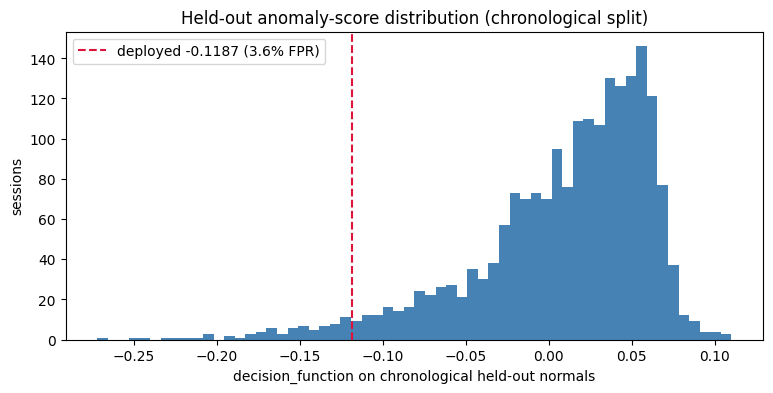

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(held.score, bins=60, color='steelblue')
ax.axvline(DEPLOYED_THRESHOLD, color='crimson', linestyle='--',
           label=f'deployed {DEPLOYED_THRESHOLD} ({overall:.1%} FPR)')
ax.set_xlabel('decision_function on chronological held-out normals')
ax.set_ylabel('sessions')
ax.set_title('Held-out anomaly-score distribution (chronological split)')
ax.legend()
plt.show()

## Pooled-cohort verification (Task 3)
Duration distributions per vendor family across the pooled tier. Coherent,
unimodal-ish families justify cohort models; the thin families (< 50
sessions) already route to the global pool (layer2_scope decision).

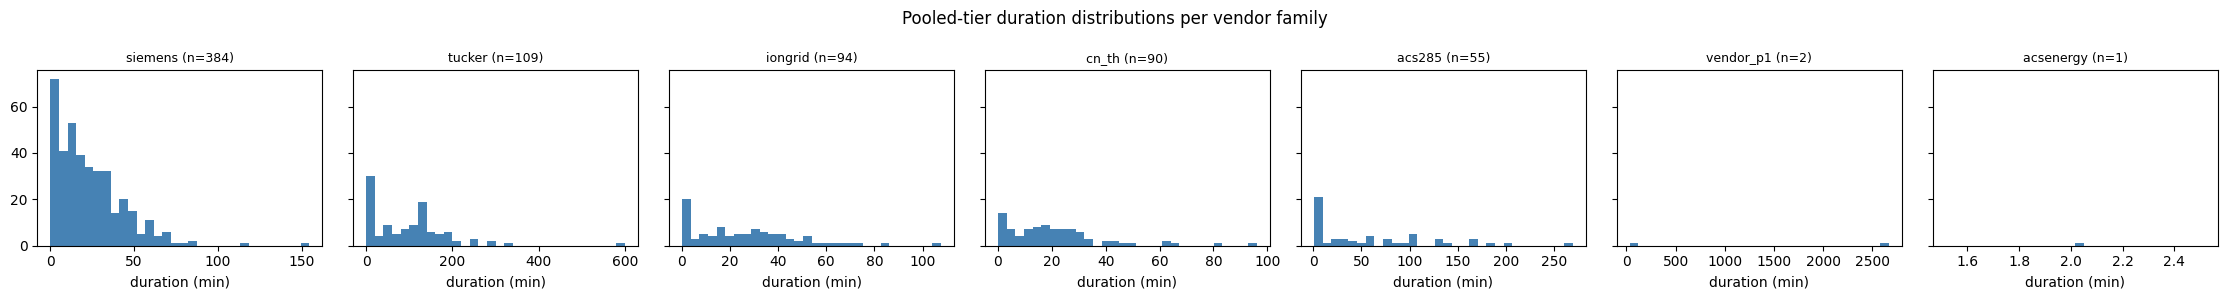

Verification: families with >=50 sessions show coherent unimodal
duration mass -> keep cohort models; thinner families stay on the
global pool. Decision recorded in docs/layer2_scope.md.


In [6]:
pooled_tier = sessions[~sessions.connector_pk.isin(per_pks)]
families = pooled_tier.family.value_counts()
fig, axes = plt.subplots(1, len(families), figsize=(3.2 * len(families), 3),
                         sharey=True)
for ax, (family, n) in zip(np.atleast_1d(axes), families.items()):
    data = pooled_tier.loc[pooled_tier.family == family, 'duration_sec'] / 60
    ax.hist(data, bins=30, color='steelblue')
    ax.set_title(f'{family} (n={n})', fontsize=9)
    ax.set_xlabel('duration (min)')
fig.suptitle('Pooled-tier duration distributions per vendor family')
fig.tight_layout()
plt.show()
print('Verification: families with >=50 sessions show coherent unimodal\n'
      'duration mass -> keep cohort models; thinner families stay on the\n'
      'global pool. Decision recorded in docs/layer2_scope.md.')